In [89]:
import os
import numpy as np
import pandas as pd
# =========================
# Clean & Optimized Imports (Visual Studio Ready)
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# visualization (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [90]:
# Example: CSV load
data_path = "final_sleep_dataDev.csv"   # path adjust করো
df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (52610, 20)


,Your Age,What is your weight,Your Height,What is your gender?,What is your occupation?,What time do you usually go to bed?,What time do you usually wake up on working days?,What time do you usually go to bed on weekends?,What time do you usually wake up on weekends?,How long does it take you to fall asleep after going to bed?,How many hours of sleep do you get on average per night?,What are the main reasons you sleep late?,Do you have difficulty falling asleep?,Do you experience breathing difficulties while sleeping,Do you experience restless legs or involuntary movements during sleep?,Do you have any medical conditions that might affect your sleep?,Do you experience any of the following side effects from late sleeping?,How often do you find it hard to concentrate due to lack of sleep?,What strategies do you use to cope with the side effects of late sleeping?,How would you rate the comfort of your sleeping environment
0,18-30,83.0,5.1,Male,Student,10 PM - 12 AM,6 AM - 8 AM,12 AM - 2 AM,8 AM - 10 AM,15-30 minutes,6-8 hours,Study & Exam Purpose;Social Media/Internet;Ent...,Rarely,Never,Sometimes,No,Fatigue ;Decreased academic or work performanc...,Sometimes,Caffeine or other stimulants ;Exercise ;Others,4
1,18-30,68.0,5.8,Male,Student,After 2 AM,8 AM - 10 AM,After 2 AM,After 10 AM,15-30 minutes,4-6 hours,Study & Exam Purpose;Social Media/Internet;Ent...,Rarely,Never,Never,Asthma,Difficulty concentrating ;Mood swings or irrit...,Sometimes,Naps during the day ;Caffeine or other stimula...,4
2,18-30,50.0,5.8,Male,Student,12 AM - 2 AM,8 AM - 10 AM,12 AM - 2 AM,8 AM - 10 AM,15-30 minutes,6-8 hours,professional Work;Study & Exam Purpose;Social ...,Never,Never,Rarely,Depression,Fatigue ;Mood swings or irritability ;Decrease...,Never,Naps during the day ;Exercise,4
3,18-30,70.0,5.5,Female,Student,12 AM - 2 AM,6 AM - 8 AM,After 2 AM,After 10 AM,More than 60 minutes,4-6 hours,Social Media/Internet;Entertainment (TV;movies...,Always,Sometimes,Sometimes,Depression,Fatigue ;Difficulty concentrating ;Mood swings...,Always,Exercise,3
4,18-30,70.0,5.6,Male,Student,12 AM - 2 AM,6 AM - 8 AM,12 AM - 2 AM,8 AM - 10 AM,Less than 15 minutes,6-8 hours,Study & Exam Purpose;Social Media/Internet;Str...,Sometimes,Rarely,Never,Anxiety Disorders,Fatigue ;Difficulty concentrating ;Mood swings...,Often,Naps during the day ;Exercise ;Others,4


In [91]:
# Check unique values in the "Do you have any medical conditions that might affect your sleep?" column
unique_conditions = df['Do you have any medical conditions that might affect your sleep?'].unique()
unique_conditions

array(['No', 'Asthma', 'Depression', 'Anxiety Disorders', nan,
       'GERD/Acidity', 'Allergies', 'Na', 'à¦¨à¦¾à¦¹', 'à¦¨à¦¾à¥¤',
       'Never', 'Insomnia', 'Obstructive Sleep Apnea',
       'Thyroid Disorders', 'Restless Legs Syndrome', 'Narcolepsy',
       'Nothing', 'Nothing Seriuos', 'Hypersomnia', 'No Disease', 'Yes',
       'N0', 'Negative', 'Sleep Talking, Diabetes', 'Chronic Pain',
       'Not Yet By The Grace Of Allah', 'Hapani', 'Yes (high Bp, Ckd)',
       'Diabetes', 'Maybe Ocd', 'Asma', 'Blood Pressure', 'Others',
       'Chronic Pain, Diabetes', 'Headaches, Asthma', 'Hypertension',
       'Arthritis', 'Daibetes', 'Diabetes, Chronic Pain',
       'Chronic Pain, Hypertension', 'Asthma, Diabetes', 'à¦¨à¦¾',
       'Other', 'Heart Disease', 'Osteoarthritis', 'Cancer',
       'Heart Diseases', 'Hearing Loss', 'High Blood Pressure', 'Stroke',
       'No.', 'Prostate Problem', 'Difficult Concentrating',
       'Kidney Pain,legs Pain', 'Dibetes', 'No Medical Condition', 'Ye',
 

In [92]:
# Create a mapping function to categorize the conditions into 4 broader categories
def categorize_conditions(condition):
    condition = str(condition).lower()

    # Treat "no" conditions and non-standard responses as 'No Condition'
    if 'no' in condition or 'none' in condition or 'nothing' in condition or 'negative' in condition or 'other' in condition or 'না' in condition or 'na' in condition:
        return 'No Condition'
    elif 'asthma' in condition or 'sleep apnea' in condition or 'chronic bronchitis' in condition:
        return 'Sleep/Respiratory Disorders'
    elif 'diabetes' in condition or 'thyroid' in condition or 'heart' in condition or 'blood pressure' in condition or 'stroke' in condition:
        return 'Health Issues'
    elif 'anxiety' in condition or 'stress' in condition or 'depression' in condition or 'chronic pain' in condition or 'arthritis' in condition:
        return 'Mental Health Issues'
    else:
        return 'No Condition'

# Apply the new categorization function to the 'Medical Condition Category' column
df['Medical Condition Category'] = df['Do you have any medical conditions that might affect your sleep?'].apply(categorize_conditions)

# Create separate binary columns for each of the 4 categories
condition_categories = [
    'No Condition',
    'Sleep/Respiratory Disorders',
    'Health Issues',
    'Mental Health Issues'
]

# Apply the categorization function to create the new column
df['Medical Condition Category'] = df['Do you have any medical conditions that might affect your sleep?'].apply(categorize_conditions)

# Display the updated dataframe to confirm the new column is added
display(df)

,Your Age,What is your weight,Your Height,What is your gender?,What is your occupation?,What time do you usually go to bed?,What time do you usually wake up on working days?,What time do you usually go to bed on weekends?,What time do you usually wake up on weekends?,How long does it take you to fall asleep after going to bed?,How many hours of sleep do you get on average per night?,What are the main reasons you sleep late?,Do you have difficulty falling asleep?,Do you experience breathing difficulties while sleeping,Do you experience restless legs or involuntary movements during sleep?,Do you have any medical conditions that might affect your sleep?,Do you experience any of the following side effects from late sleeping?,How often do you find it hard to concentrate due to lack of sleep?,What strategies do you use to cope with the side effects of late sleeping?,How would you rate the comfort of your sleeping environment,Medical Condition Category
0,18-30,83.0,5.10,Male,Student,10 PM - 12 AM,6 AM - 8 AM,12 AM - 2 AM,8 AM - 10 AM,15-30 minutes,6-8 hours,Study & Exam Purpose;Social Media/Internet;Ent...,Rarely,Never,Sometimes,No,Fatigue ;Decreased academic or work performanc...,Sometimes,Caffeine or other stimulants ;Exercise ;Others,4,No Condition
1,18-30,68.0,5.80,Male,Student,After 2 AM,8 AM - 10 AM,After 2 AM,After 10 AM,15-30 minutes,4-6 hours,Study & Exam Purpose;Social Media/Internet;Ent...,Rarely,Never,Never,Asthma,Difficulty concentrating ;Mood swings or irrit...,Sometimes,Naps during the day ;Caffeine or other stimula...,4,Sleep/Respiratory Disorders
2,18-30,50.0,5.80,Male,Student,12 AM - 2 AM,8 AM - 10 AM,12 AM - 2 AM,8 AM - 10 AM,15-30 minutes,6-8 hours,professional Work;Study & Exam Purpose;Social ...,Never,Never,Rarely,Depression,Fatigue ;Mood swings or irritability ;Decrease...,Never,Naps during the day ;Exercise,4,Mental Health Issues
3,18-30,70.0,5.50,Female,Student,12 AM - 2 AM,6 AM - 8 AM,After 2 AM,After 10 AM,More than 60 minutes,4-6 hours,Social Media/Internet;Entertainment (TV;movies...,Always,Sometimes,Sometimes,Depression,Fatigue ;Difficulty concentrating ;Mood swings...,Always,Exercise,3,Mental Health Issues
4,18-30,70.0,5.60,Male,Student,12 AM - 2 AM,6 AM - 8 AM,12 AM - 2 AM,8 AM - 10 AM,Less than 15 minutes,6-8 hours,Study & Exam Purpose;Social Media/Internet;Str...,Sometimes,Rarely,Never,Anxiety Disorders,Fatigue ;Difficulty concentrating ;Mood swings...,Often,Naps during the day ;Exercise ;Others,4,Mental Health Issues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52605,Under 18,64.9,4.86,Male,Student,Before 10 PM,Before 6 AM,Before 10 PM,After 10 AM,Less than 15 minutes,6-8 hours,Study & Exam Purpose;Social Media/Internet;Str...,Rarely,Never,Never,Chronic Pain,Difficulty concentrating,Sometimes,Naps during the day,4,Mental Health Issues
52606,18-30,70.4,5.39,Male,Student,Before 10 PM,Before 6 AM,10 PM - 12 AM,8 AM - 10 AM,Less than 15 minutes,6-8 hours,Study & Exam Purpose;Social Media/Internet;Str...,Never,Never,Often,Chronic Pain,Difficulty concentrating;Decreased academic or...,Always,Relaxation techniques,4,Mental Health Issues
52607,18-30,63.4,5.28,Male,Student,12 AM - 2 AM,After 10 AM,Before 10 PM,After 10 AM,More than 60 minutes,More than 8 hours,Social Media/Internet;Entertainment (TV;movies...,Always,Often,Sometimes,No,Fatigue;Mood swings or irritability;Decreased ...,Never,Naps during the day;Exercise,4,No Condition
52608,31-50,55.9,5.16,Female,Working Professional,10 PM - 12 AM,6 AM - 8 AM,10 PM - 12 AM,8 AM - 10 AM,Less than 15 minutes,6-8 hours,Study & Exam Purpose;Social Media/Internet;Ent...,Always,Never,Never,Allergies,Fatigue;Mood swings or irritability,Never,Naps during the day,3,No Condition


<Axes: >

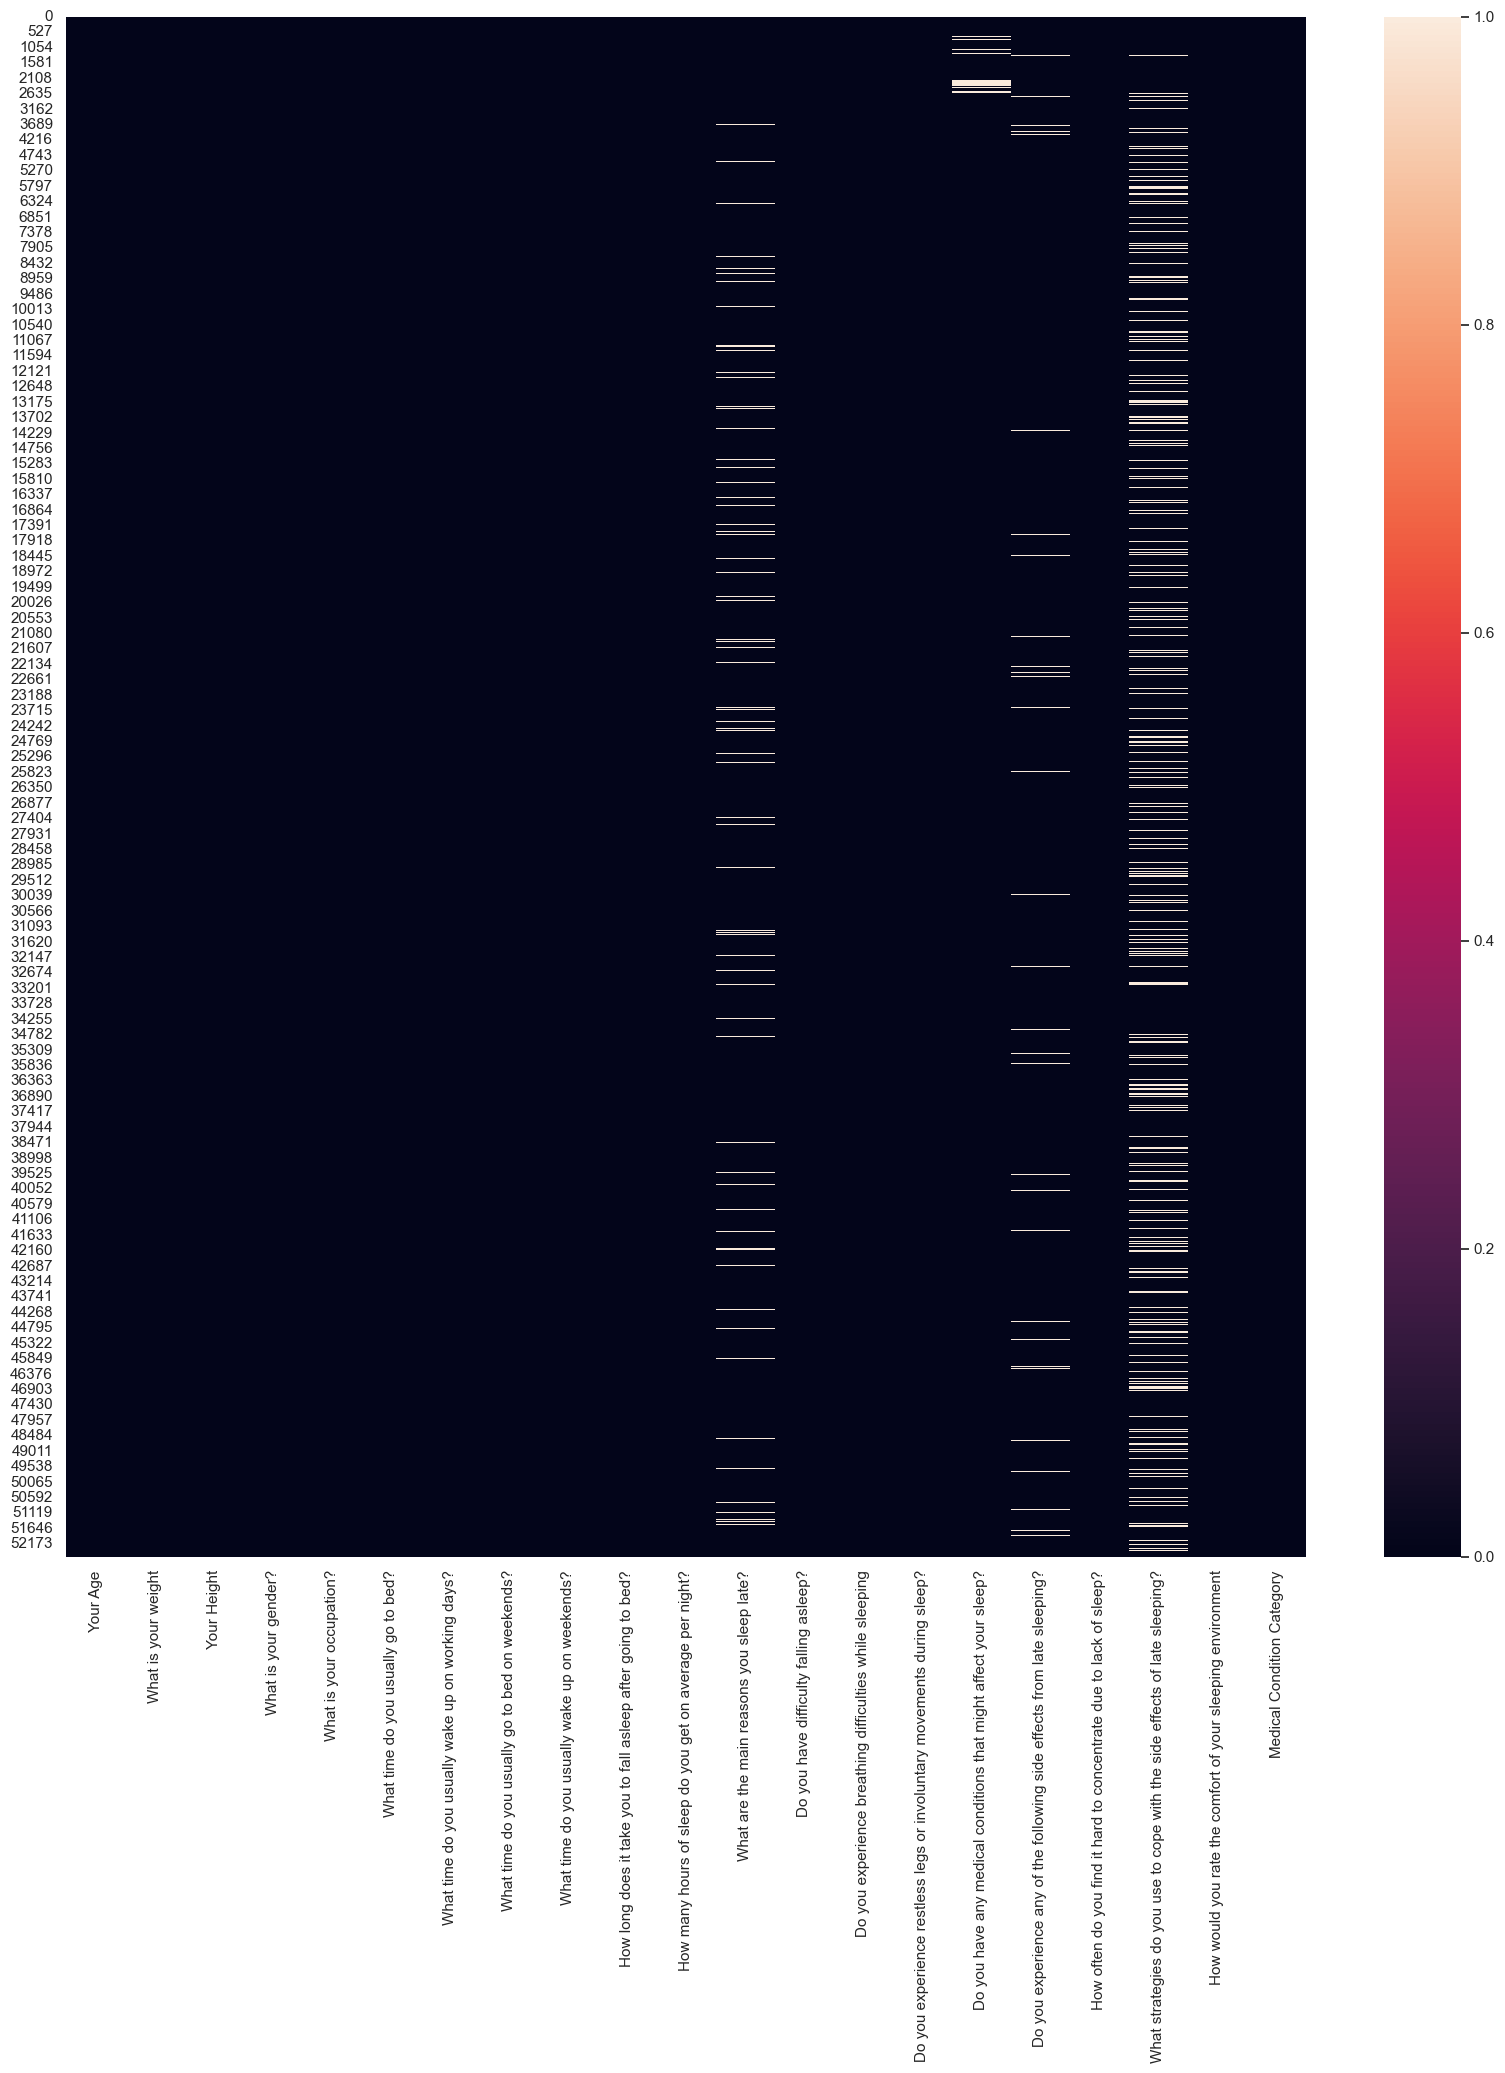

In [93]:
plt.figure(figsize=(20,20))
sb.heatmap(df.isnull())

In [94]:
null_percentage = df.isnull().sum() * 100 / len(df)
print(null_percentage)

Your Age                                                                       0.000000
What is your weight                                                            0.001901
Your Height                                                                    0.011405
What is your gender?                                                           0.001901
What is your occupation?                                                       0.001901
What time do you usually go to bed?                                            0.000000
What time do you usually wake up on working days?                              0.000000
What time do you usually go to bed on weekends?                                0.000000
What time do you usually wake up on weekends?                                  0.000000
How long does it take you to fall asleep after going to bed?                   0.001901
How many hours of sleep do you get on average per night?                       0.000000
What are the main reasons you sl

In [95]:
for col in df.columns:
  if df[col].isnull().any():
    if df[col].dtype == 'object':
      df[col] = df[col].fillna(df[col].mode()[0])
    else:
      df[col] = df[col].fillna(df[col].median())

In [96]:
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid modifying original dataset
df_encoded = df.copy()

In [97]:
from sklearn.preprocessing import LabelEncoder

# Define a mapping for age categorization
age_mapping = {
    'Under 18': 0,
    '18-30': 0,
    '31-50': 1,
    'Above 50': 2
}

# Apply the mapping to the 'Your Age' column
df_encoded['Your Age'] = df_encoded['Your Age'].map(age_mapping)

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding to the mapped column
df_encoded['Your Age'] = label_encoder.fit_transform(df_encoded['Your Age'])

# Display the updated column to verify the encoding
display(df_encoded['Your Age'].value_counts())

Your Age
0    36422
1    10704
2     5484
Name: count, dtype: int64

In [98]:
# Create a mapping to group 'Unemployment' and 'Others'
occupation_grouping = {
    'Student': 'Student',
    'Working Professional': 'Working Professional',
    'Unemployment': 'Unemployment/Others',
    'Others': 'Unemployment/Others',
    'Freelancing': 'Freelancing',
    'Housewife': 'Housewife'
}

# Apply the grouping to the 'What is your occupation?' column
df_encoded['What is your occupation?'] = df_encoded['What is your occupation?'].map(occupation_grouping)

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding to the grouped occupation column
df_encoded['What is your occupation?'] = label_encoder.fit_transform(df_encoded['What is your occupation?'])

# Get the mapping of encoded labels to original categories
occupation_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

# Display the updated column to verify the encoding
display(df_encoded['What is your occupation?'].value_counts())

# Display the occupation mapping
print("\nOccupation Mapping:")
print(occupation_mapping)

What is your occupation?
2    21459
4    16186
3     8593
0     5344
1     1028
Name: count, dtype: int64


Occupation Mapping:
{'Freelancing': 0, 'Housewife': 1, 'Student': 2, 'Unemployment/Others': 3, 'Working Professional': 4}


In [99]:
# Get the indices of rows where gender is 'Prefer not to say'
prefer_not_to_say_indices = df_encoded[df_encoded['What is your gender?'] == 'Prefer not to say'].index

# Calculate the number of rows to convert to male and female
num_prefer_not_to_say = len(prefer_not_to_say_indices)
num_male = num_prefer_not_to_say // 2
num_female = num_prefer_not_to_say - num_male

# Randomly select indices for male and female assignment
male_indices = np.random.choice(prefer_not_to_say_indices, size=num_male, replace=False)
female_indices = np.random.choice([i for i in prefer_not_to_say_indices if i not in male_indices], size=num_female, replace=False)

# Update the gender in the df_encoded DataFrame
df_encoded.loc[male_indices, 'What is your gender?'] = 'Male'
df_encoded.loc[female_indices, 'What is your gender?'] = 'Female'

# Verify the changes
display(df_encoded['What is your gender?'].value_counts())

What is your gender?
Female    26827
Male      25783
Name: count, dtype: int64

In [100]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding to the 'What is your gender?' column
df_encoded['What is your gender?'] = label_encoder.fit_transform(df_encoded['What is your gender?'])

# Display the updated column to verify the encoding
display(df_encoded['What is your gender?'].value_counts())



What is your gender?
0    26827
1    25783
Name: count, dtype: int64

In [101]:
# List of columns to exclude from automatic encoding
excluded_columns = [
    'What are the main reasons you sleep late?',
    'Do you experience any of the following side effects from late sleeping?',
    'What strategies do you use to cope with the side effects of late sleeping?',
    'Your Age',
    'What is your occupation?',
    'What is your gender?',
    'What is your weight', # Numerical column
    'Your Height', # Numerical column
    'How would you rate the comfort of your sleeping environment' # Numerical column

]

# Identify remaining object type columns
categorical_cols_to_encode = [col for col in df_encoded.select_dtypes(include='object').columns if col not in excluded_columns]

print("Categorical columns to encode:")
print(categorical_cols_to_encode)

# Apply Label Encoding to the remaining categorical columns
label_encoder = LabelEncoder()
for col in categorical_cols_to_encode:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])
    print(f"\nEncoding for column: {col}")
    print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# Display the first few rows of the updated dataframe
display(df_encoded.head())

Categorical columns to encode:
['What time do you usually go to bed?', 'What time do you usually wake up on working days?', 'What time do you usually go to bed on weekends?', 'What time do you usually wake up on weekends?', 'How long does it take you to fall asleep after going to bed?', 'How many hours of sleep do you get on average per night?', 'Do you have difficulty falling asleep?', 'Do you experience breathing difficulties while sleeping', 'Do you experience restless legs or involuntary movements during sleep?', 'Do you have any medical conditions that might affect your sleep?', 'How often do you find it hard to concentrate due to lack of sleep?', 'Medical Condition Category']

Encoding for column: What time do you usually go to bed?
{'10 PM - 12 AM': 0, '12 AM - 2 AM': 1, 'After 2 AM': 2, 'Before 10 PM': 3}

Encoding for column: What time do you usually wake up on working days?
{'6 AM - 8 AM': 0, '8 AM - 10 AM': 1, 'After 10 AM': 2, 'Before 6 AM': 3}

Encoding for column: What ti

,Your Age,What is your weight,Your Height,What is your gender?,What is your occupation?,What time do you usually go to bed?,What time do you usually wake up on working days?,What time do you usually go to bed on weekends?,What time do you usually wake up on weekends?,How long does it take you to fall asleep after going to bed?,How many hours of sleep do you get on average per night?,What are the main reasons you sleep late?,Do you have difficulty falling asleep?,Do you experience breathing difficulties while sleeping,Do you experience restless legs or involuntary movements during sleep?,Do you have any medical conditions that might affect your sleep?,Do you experience any of the following side effects from late sleeping?,How often do you find it hard to concentrate due to lack of sleep?,What strategies do you use to cope with the side effects of late sleeping?,How would you rate the comfort of your sleeping environment,Medical Condition Category
0,0,83.0,5.1,1,2,0,0,1,1,0,1,Study & Exam Purpose;Social Media/Internet;Ent...,3,1,4,53,Fatigue ;Decreased academic or work performanc...,4,Caffeine or other stimulants ;Exercise ;Others,4,2
1,0,68.0,5.8,1,2,2,1,2,2,0,0,Study & Exam Purpose;Social Media/Internet;Ent...,3,1,1,7,Difficulty concentrating ;Mood swings or irrit...,4,Naps during the day ;Caffeine or other stimula...,4,3
2,0,50.0,5.8,1,2,1,1,1,1,0,1,professional Work;Study & Exam Purpose;Social ...,1,1,3,20,Fatigue ;Mood swings or irritability ;Decrease...,1,Naps during the day ;Exercise,4,1
3,0,70.0,5.5,0,2,1,0,2,2,3,0,Social Media/Internet;Entertainment (TV;movies...,0,4,4,20,Fatigue ;Difficulty concentrating ;Mood swings...,0,Exercise,3,1
4,0,70.0,5.6,1,2,1,0,1,1,2,1,Study & Exam Purpose;Social Media/Internet;Str...,4,3,1,2,Fatigue ;Difficulty concentrating ;Mood swings...,2,Naps during the day ;Exercise ;Others,4,1


In [102]:
# Split the side effects and apply One-Hot Encoding
side_effects_late_sleep = df_encoded['Do you experience any of the following side effects from late sleeping?'].str.get_dummies(sep=';')

# Concatenate the new columns to the dataframe and drop the original column
df_encoded = pd.concat([df_encoded, side_effects_late_sleep], axis=1)
df_encoded = df_encoded.drop('Do you experience any of the following side effects from late sleeping?', axis=1)

# Display the first few rows of the updated dataframe
display(df_encoded.head())

,Your Age,What is your weight,Your Height,What is your gender?,What is your occupation?,What time do you usually go to bed?,What time do you usually wake up on working days?,What time do you usually go to bed on weekends?,What time do you usually wake up on weekends?,How long does it take you to fall asleep after going to bed?,How many hours of sleep do you get on average per night?,What are the main reasons you sleep late?,Do you have difficulty falling asleep?,Do you experience breathing difficulties while sleeping,Do you experience restless legs or involuntary movements during sleep?,Do you have any medical conditions that might affect your sleep?,How often do you find it hard to concentrate due to lack of sleep?,What strategies do you use to cope with the side effects of late sleeping?,How would you rate the comfort of your sleeping environment,Medical Condition Category,Back Pain,Back Pain,Decreased academic or work performance,Decreased academic or work performance,Difficulty concentrating,Difficulty concentrating,Fatigue,Fatigue,Health issues,Health issues ),Mood swings or irritability,Mood swings or irritability,Others,Others
0,0,83.0,5.1,1,2,0,0,1,1,0,1,Study & Exam Purpose;Social Media/Internet;Ent...,3,1,4,53,4,Caffeine or other stimulants ;Exercise ;Others,4,2,0,0,0,1,0,0,0,1,0,1,0,0,0,0
1,0,68.0,5.8,1,2,2,1,2,2,0,0,Study & Exam Purpose;Social Media/Internet;Ent...,3,1,1,7,4,Naps during the day ;Caffeine or other stimula...,4,3,0,0,0,0,0,1,0,0,0,1,0,1,0,0
2,0,50.0,5.8,1,2,1,1,1,1,0,1,professional Work;Study & Exam Purpose;Social ...,1,1,3,20,1,Naps during the day ;Exercise,4,1,0,0,0,1,0,0,0,1,0,1,0,1,0,0
3,0,70.0,5.5,0,2,1,0,2,2,3,0,Social Media/Internet;Entertainment (TV;movies...,0,4,4,20,0,Exercise,3,1,0,0,0,1,0,1,0,1,0,1,0,1,0,0
4,0,70.0,5.6,1,2,1,0,1,1,2,1,Study & Exam Purpose;Social Media/Internet;Str...,4,3,1,2,2,Naps during the day ;Exercise ;Others,4,1,0,0,0,1,0,1,0,1,0,1,0,1,0,0


In [103]:
# Split the reasons and apply One-Hot Encoding to 'What are the main reasons you sleep late?' column
reasons_late_sleep = df_encoded['What are the main reasons you sleep late?'].str.get_dummies(sep=';')

# Concatenate the new columns to the dataframe and drop the original column
df_encoded = pd.concat([df_encoded, reasons_late_sleep], axis=1)
df_encoded = df_encoded.drop('What are the main reasons you sleep late?', axis=1)

# Display the first few rows of the updated dataframe
display(df_encoded.head())

,Your Age,What is your weight,Your Height,What is your gender?,What is your occupation?,What time do you usually go to bed?,What time do you usually wake up on working days?,What time do you usually go to bed on weekends?,What time do you usually wake up on weekends?,How long does it take you to fall asleep after going to bed?,How many hours of sleep do you get on average per night?,Do you have difficulty falling asleep?,Do you experience breathing difficulties while sleeping,Do you experience restless legs or involuntary movements during sleep?,Do you have any medical conditions that might affect your sleep?,How often do you find it hard to concentrate due to lack of sleep?,What strategies do you use to cope with the side effects of late sleeping?,How would you rate the comfort of your sleeping environment,Medical Condition Category,Back Pain,Back Pain,Decreased academic or work performance,Decreased academic or work performance,Difficulty concentrating,Difficulty concentrating,Fatigue,Fatigue,Health issues,Health issues ),Mood swings or irritability,Mood swings or irritability,Others,Others,Entertainment (TV,Insomnia or other sleep disorder,Others,Social Media/Internet,Stress or anxiety,Study & Exam Purpose,games),movies,professional Work
0,0,83.0,5.1,1,2,0,0,1,1,0,1,3,1,4,53,4,Caffeine or other stimulants ;Exercise ;Others,4,2,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,1,0,1,1,1,1,1,0
1,0,68.0,5.8,1,2,2,1,2,2,0,0,3,1,1,7,4,Naps during the day ;Caffeine or other stimula...,4,3,0,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,1,1,1,1,1,0
2,0,50.0,5.8,1,2,1,1,1,1,0,1,1,1,3,20,1,Naps during the day ;Exercise,4,1,0,0,0,1,0,0,0,1,0,1,0,1,0,0,1,0,0,1,0,1,1,1,1
3,0,70.0,5.5,0,2,1,0,2,2,3,0,0,4,4,20,0,Exercise,3,1,0,0,0,1,0,1,0,1,0,1,0,1,0,0,1,1,0,1,1,0,1,1,0
4,0,70.0,5.6,1,2,1,0,1,1,2,1,4,3,1,2,2,Naps during the day ;Exercise ;Others,4,1,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,1,1,1,0,0,0


In [104]:
# Get the number of unique side effects after one-hot encoding
num_side_effects = side_effects_late_sleep.shape[1]

# Print the number of options
print(f"Total number of side effect options: {num_side_effects}")

# Optionally, print the side effect options
print("\nSide effect options:")
print(side_effects_late_sleep.columns.tolist())

Total number of side effect options: 14

Side effect options:
['Back Pain', 'Back Pain ', 'Decreased academic or work performance', 'Decreased academic or work performance ', 'Difficulty concentrating', 'Difficulty concentrating ', 'Fatigue', 'Fatigue ', 'Health issues', 'Health issues  )', 'Mood swings or irritability', 'Mood swings or irritability ', 'Others', 'Others ']


In [105]:
# Split the strategies and get the unique strategies
strategies = df_encoded['What strategies do you use to cope with the side effects of late sleeping?'].str.get_dummies(sep=';')

# Get the number of unique strategies
num_strategies = strategies.shape[1]

# Print the number of options
print(f"Total number of strategy options: {num_strategies}")

# Optionally, print the strategy options
print("\nStrategy options:")
print(strategies.columns.tolist())

Total number of strategy options: 10

Strategy options:
['Caffeine or other stimulants', 'Caffeine or other stimulants ', 'Exercise', 'Exercise ', 'Naps during the day', 'Naps during the day ', 'Others', 'Others ', 'Relaxation techniques', 'Relaxation techniques  )']


In [106]:
# Split the strategies and apply One-Hot Encoding
strategies_encoded = df_encoded['What strategies do you use to cope with the side effects of late sleeping?'].str.get_dummies(sep=';')

# Concatenate the new columns to the dataframe and drop the original column
df_encoded = pd.concat([df_encoded, strategies_encoded], axis=1)
df_encoded = df_encoded.drop('What strategies do you use to cope with the side effects of late sleeping?', axis=1)

# Display the first few rows of the updated dataframe
display(df_encoded.head())

,Your Age,What is your weight,Your Height,What is your gender?,What is your occupation?,What time do you usually go to bed?,What time do you usually wake up on working days?,What time do you usually go to bed on weekends?,What time do you usually wake up on weekends?,How long does it take you to fall asleep after going to bed?,How many hours of sleep do you get on average per night?,Do you have difficulty falling asleep?,Do you experience breathing difficulties while sleeping,Do you experience restless legs or involuntary movements during sleep?,Do you have any medical conditions that might affect your sleep?,How often do you find it hard to concentrate due to lack of sleep?,How would you rate the comfort of your sleeping environment,Medical Condition Category,Back Pain,Back Pain,Decreased academic or work performance,Decreased academic or work performance,Difficulty concentrating,Difficulty concentrating,Fatigue,Fatigue,Health issues,Health issues ),Mood swings or irritability,Mood swings or irritability,Others,Others,Entertainment (TV,Insomnia or other sleep disorder,Others,Social Media/Internet,Stress or anxiety,Study & Exam Purpose,games),movies,professional Work,Caffeine or other stimulants,Caffeine or other stimulants,Exercise,Exercise,Naps during the day,Naps during the day,Others,Others,Relaxation techniques,Relaxation techniques )
0,0,83.0,5.1,1,2,0,0,1,1,0,1,3,1,4,53,4,4,2,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,1,0,1,1,1,1,1,0,0,1,0,1,0,0,1,0,0,0
1,0,68.0,5.8,1,2,2,1,2,2,0,0,3,1,1,7,4,4,3,0,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,1,1,1,1,1,0,0,1,0,0,0,1,0,0,0,1
2,0,50.0,5.8,1,2,1,1,1,1,0,1,1,1,3,20,1,4,1,0,0,0,1,0,0,0,1,0,1,0,1,0,0,1,0,0,1,0,1,1,1,1,0,0,1,0,0,1,0,0,0,0
3,0,70.0,5.5,0,2,1,0,2,2,3,0,0,4,4,20,0,3,1,0,0,0,1,0,1,0,1,0,1,0,1,0,0,1,1,0,1,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0
4,0,70.0,5.6,1,2,1,0,1,1,2,1,4,3,1,2,2,4,1,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,1,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0


In [110]:
# =========================
# Remove Duplicate Columns (df_encoded)
# =========================

def clean_col_name(col):
    return col.strip().replace(" )", "")

# Clean column names
df_encoded.columns = [clean_col_name(col) for col in df_encoded.columns]

# Remove duplicate columns
df_encoded = df_encoded.loc[:, ~df_encoded.columns.duplicated()]

# Show total columns
print("Total Columns:", df_encoded.shape[1])

Total Columns: 39


In [112]:
# =========================
# Fix Specific Duplicate Columns (df_encoded)
# =========================

# Clean column names (remove spaces + artifacts)
df_encoded.columns = df_encoded.columns.str.strip().str.replace(" )", "", regex=False)

# Merge duplicate columns by summing values
df_encoded = df_encoded.groupby(df_encoded.columns, axis=1).sum()

# Show total columns
print("Total Columns:", df_encoded.shape[1])

# Verify specific columns
print("\nCheck Columns:")
print([col for col in df_encoded.columns if "Relaxation techniques" in col])
print([col for col in df_encoded.columns if "Health issues" in col])

Total Columns: 37

Check Columns:
['Relaxation techniques']
['Health issues']


In [113]:
# =========================
# Show Column Names (df_encoded)
# =========================

for i, col in enumerate(df_encoded.columns, 1):
    print(f"{i}. {col}")

1. Back Pain
2. Caffeine or other stimulants
3. Decreased academic or work performance
4. Difficulty concentrating
5. Do you experience breathing difficulties while sleeping
6. Do you experience restless legs or involuntary movements during sleep?
7. Do you have any medical conditions that might affect your sleep?
8. Do you have difficulty falling asleep?
9. Entertainment (TV
10. Exercise
11. Fatigue
12. Health issues
13. How long does it take you to fall asleep after going to bed?
14. How many hours of sleep do you get on average per night?
15. How often do you find it hard to concentrate due to lack of sleep?
16. How would you rate the comfort of your sleeping environment
17. Insomnia or other sleep disorder
18. Medical Condition Category
19. Mood swings or irritability
20. Naps during the day
21. Others
22. Relaxation techniques
23. Social Media/Internet
24. Stress or anxiety
25. Study & Exam Purpose
26. What is your gender?
27. What is your occupation?
28. What is your weight
29. W

In [115]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [116]:
%pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 8.2 MB/s eta 0:00:01
   -------------- ------------------------- 0.5/1.5 MB 8.2 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [121]:
# =========================
# Complete Pipeline (No Missing Variable Error)
# =========================

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import lightgbm as lgb
import numpy as np

# -------- Step 1: Define X and y --------
target_column = 'Medical Condition Category'

X = df_encoded.drop(target_column, axis=1)
y = df_encoded[target_column]

# -------- Step 2: Train-Test Split --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -------- Step 3: Keep Only Numeric --------
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

# Align columns
X_test_numeric = X_test_numeric[X_train_numeric.columns]

# -------- Step 4: Apply SMOTE --------
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_numeric, y_train)

# -------- Step 5: Feature Selection --------
selector = SelectKBest(score_func=mutual_info_classif, k=15)
selector.fit(X_train_resampled, y_train_resampled)

selected_features = X_train_numeric.columns[selector.get_support()].tolist()

X_train_selected = X_train_resampled[selected_features]
X_test_selected = X_test_numeric[selected_features]

print("Selected Features:")
print(selected_features)

Selected Features:
['Do you experience restless legs or involuntary movements during sleep?', 'Do you have any medical conditions that might affect your sleep?', 'Do you have difficulty falling asleep?', 'How long does it take you to fall asleep after going to bed?', 'How many hours of sleep do you get on average per night?', 'How often do you find it hard to concentrate due to lack of sleep?', 'How would you rate the comfort of your sleeping environment', 'Mood swings or irritability', 'What is your gender?', 'What is your occupation?', 'What is your weight', 'What time do you usually go to bed on weekends?', 'What time do you usually go to bed?', 'What time do you usually wake up on weekends?', 'Your Height']


In [122]:
# =========================
# Train Multiple Models (RandomForest, KNN, XGBoost)
# =========================

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# -------- Initialize Models --------
rf_model = RandomForestClassifier(random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

models = {
    "Random Forest": rf_model,
    "KNN": knn_model,
    "XGBoost": xgb_model
}

# -------- Train + Evaluate --------
for name, model in models.items():
    model.fit(X_train_selected, y_train_resampled)
    y_pred = model.predict(X_test_selected)

    train_acc = model.score(X_train_selected, y_train_resampled)
    test_acc = accuracy_score(y_test, y_pred)

    print(f"\n{name}")
    print(f"Train Accuracy: {train_acc * 100:.2f}%")
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Random Forest
Train Accuracy: 100.00%
Test Accuracy: 99.46%
Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.98      0.99       898
         1.0       1.00      1.00      1.00      3670
         2.0       0.99      1.00      1.00      9066
         3.0       1.00      0.98      0.99      2149

    accuracy                           0.99     15783
   macro avg       1.00      0.99      0.99     15783
weighted avg       0.99      0.99      0.99     15783

Confusion Matrix:
 [[ 881    0   16    1]
 [   0 3663    7    0]
 [   6    1 9058    1]
 [   0    1   52 2096]]

KNN
Train Accuracy: 99.63%
Test Accuracy: 98.54%
Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       898
         1.0       0.96      1.00      0.98      3670
         2.0       1.00      0.98      0.99      9066
         3.0       0.98      1.00      0.99      2149

    accuracy          

In [124]:
# =========================
# Fix: Define RandomForest Model + Cross Validation
# =========================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Define model (use this if best_rf_model not available)
rf_model = RandomForestClassifier(random_state=42)

# Cross-validation
cv_scores = cross_val_score(
    rf_model,
    X_train_selected,
    y_train_resampled,
    cv=5,
    scoring='f1_macro'
)

# Results
print("Cross-validation f1_macro scores for each fold:")
print(cv_scores)

print("\nMean f1_macro:", np.mean(cv_scores))
print("Std Dev:", np.std(cv_scores))

Cross-validation f1_macro scores for each fold:
[0.94038666 0.99882184 0.99941077 0.99970541 0.99964648]

Mean f1_macro: 0.987594234013744
Std Dev: 0.0236058566290636


In [125]:
# =========================
# Refined Categorization + Feature Selection + SMOTE (Clean VS Version)
# =========================

import re
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# -------- Step 1: Categorization --------
def categorize_conditions_refined(condition):
    condition = str(condition).lower().strip()

    no_conditions = [
        'no', 'none', 'nothing', 'negative', 'na', 'না', 'নাহ',
        'nothing seriuos', 'no disease', 'n0', 'nope',
        'not yet by the grace of allah', 'no.', 'no medical condition'
    ]
    if any(k in condition for k in no_conditions):
        return 'No Condition'

    sleep_respiratory = [
        'asthma', 'sleep apnea', 'chronic bronchitis',
        'sleep talking', 'sleep paralysis',
        'deviated septum', 'hypersomnia', 'narcolepsy'
    ]
    if any(k in condition for k in sleep_respiratory):
        return 'Sleep/Respiratory Disorders'

    health_issues = [
        'diabetes', 'thyroid', 'heart', 'blood pressure',
        'stroke', 'hypertension', 'arthritis', 'kidney',
        'cancer', 'prostate', 'gerd', 'migraine', 'cold', 'health issues'
    ]
    if any(k in condition for k in health_issues):
        return 'Health Issues'

    mental_health = [
        'anxiety', 'stress', 'depression', 'chronic pain', 'tension', 'ocd'
    ]
    if any(k in condition for k in mental_health):
        return 'Mental Health Issues'

    if condition in ['yes', 'yes (high bp, ckd)', 'maybe']:
        return 'Health Issues'

    return 'Others'


# Apply categorization
df_encoded['Medical Condition Category'] = df[
    'Do you have any medical conditions that might affect your sleep?'
].apply(categorize_conditions_refined)

# -------- Step 2: Label Encoding --------
label_encoder = LabelEncoder()
df_encoded['Medical Condition Category'] = label_encoder.fit_transform(
    df_encoded['Medical Condition Category']
)

print("Label Mapping:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# -------- Step 3: Define X, y --------
target_column = 'Medical Condition Category'
X = df_encoded.drop(target_column, axis=1)
y = df_encoded[target_column]

# -------- Step 4: Numeric Only + Clean Columns --------
X_numeric = X.select_dtypes(include=np.number)

clean_cols = []
for col in X_numeric.columns:
    col = re.sub(r'[<>,\[\]]', '_', col)
    col = re.sub(r'[^A-Za-z0-9_]+', '', col)
    clean_cols.append(col)

X_numeric.columns = clean_cols

# -------- Step 5: Mutual Information --------
selector = SelectKBest(score_func=mutual_info_classif, k=15)
selector.fit(X_numeric, y)

selected_features = X_numeric.columns[selector.get_support()].tolist()
X_selected = X_numeric[selected_features]

print("\nSelected Features:")
print(selected_features)

# -------- Step 6: Train-Test Split --------
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, random_state=42
)

# -------- Step 7: SMOTE --------
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Label Mapping:
{'Health Issues': 0, 'Mental Health Issues': 1, 'No Condition': 2, 'Others': 3, 'Sleep/Respiratory Disorders': 4}

Selected Features:
['Caffeineorotherstimulants', 'Decreasedacademicorworkperformance', 'Difficultyconcentrating', 'Doyouexperiencerestlesslegsorinvoluntarymovementsduringsleep', 'Doyouhaveanymedicalconditionsthatmightaffectyoursleep', 'Doyouhavedifficultyfallingasleep', 'Fatigue', 'Howoftendoyoufindithardtoconcentrateduetolackofsleep', 'Relaxationtechniques', 'StudyExamPurpose', 'Whatisyouroccupation', 'Whattimedoyouusuallygotobedonweekends', 'Whattimedoyouusuallywakeuponweekends', 'Whattimedoyouusuallywakeuponworkingdays', 'games']

Before SMOTE:
Medical Condition Category
3    9183
1    8535
2    7872
0    6144
4    5093
Name: count, dtype: int64

After SMOTE:
Medical Condition Category
0    9183
3    9183
1    9183
2    9183
4    9183
Name: count, dtype: int64


In [126]:
# =========================
# Fix: Use Selected Features Consistently
# =========================

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------- Initialize Models --------
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
svc_model = SVC(random_state=42)

# -------- Train Models --------
rf_model.fit(X_train_resampled, y_train_resampled)
lr_model.fit(X_train_resampled, y_train_resampled)
svc_model.fit(X_train_resampled, y_train_resampled)

# -------- Use SAME features for test --------
X_test_final = X_test[X_train_resampled.columns]

# -------- Predictions --------
y_pred_rf = rf_model.predict(X_test_final)
y_pred_lr = lr_model.predict(X_test_final)
y_pred_svc = svc_model.predict(X_test_final)

# -------- Evaluation --------
def evaluate(name, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

evaluate("RandomForestClassifier", y_pred_rf)
evaluate("LogisticRegression", y_pred_lr)
evaluate("SVC", y_pred_svc)


RandomForestClassifier
Accuracy: 0.9904327440917443
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      2633
           1       0.99      1.00      1.00      3662
           2       1.00      1.00      1.00      3316
           3       0.98      0.99      0.99      3986
           4       0.98      0.98      0.98      2186

    accuracy                           0.99     15783
   macro avg       0.99      0.99      0.99     15783
weighted avg       0.99      0.99      0.99     15783

Confusion Matrix:
 [[2574   10    4   34   11]
 [   2 3654    0    4    2]
 [   0    0 3316    0    0]
 [   6    0    2 3950   28]
 [   1   14    0   33 2138]]

LogisticRegression
Accuracy: 0.4112652854336945
Classification Report:
               precision    recall  f1-score   support

           0       0.11      0.08      0.09      2633
           1       0.49      0.74      0.58      3662
           2       0.63      1.00     

In [127]:
# =========================
# Fix: Align Test Features with Training Features
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------- Ensure same columns --------
X_test_final = X_test[X_train_resampled.columns]

# -------- Initialize Models --------
lr_model = LogisticRegression(random_state=42, max_iter=1000)
svc_model = SVC(random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)
knn_model = KNeighborsClassifier()

# -------- Train --------
lr_model.fit(X_train_resampled, y_train_resampled)
svc_model.fit(X_train_resampled, y_train_resampled)
dt_model.fit(X_train_resampled, y_train_resampled)
knn_model.fit(X_train_resampled, y_train_resampled)

# -------- Predict --------
y_pred_lr = lr_model.predict(X_test_final)
y_pred_svc = svc_model.predict(X_test_final)
y_pred_dt = dt_model.predict(X_test_final)
y_pred_knn = knn_model.predict(X_test_final)

# -------- Evaluation Function --------
def evaluate(name, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# -------- Evaluate --------
evaluate("LogisticRegression", y_pred_lr)
evaluate("SVC", y_pred_svc)
evaluate("DecisionTree", y_pred_dt)
evaluate("KNN", y_pred_knn)


LogisticRegression
Accuracy: 0.4112652854336945
Classification Report:
               precision    recall  f1-score   support

           0       0.11      0.08      0.09      2633
           1       0.49      0.74      0.58      3662
           2       0.63      1.00      0.77      3316
           3       0.25      0.07      0.11      3986
           4       0.00      0.00      0.00      2186

    accuracy                           0.41     15783
   macro avg       0.30      0.38      0.31     15783
weighted avg       0.33      0.41      0.34     15783

Confusion Matrix:
 [[ 206   11  545  677 1194]
 [   1 2695    7  145  814]
 [   8    0 3308    0    0]
 [1586 1462  629  281   28]
 [   0 1384  801    0    1]]

SVC
Accuracy: 0.9818792371538998
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96      2633
           1       1.00      1.00      1.00      3662
           2       1.00      1.00      1.00      3316
   

DecisionTree - Train Accuracy: 100.00%
DecisionTree - Test Accuracy: 99.90%

CV Scores: [0.99912883 0.99945552 0.99956441 0.99934662 0.99934662]
Mean: 0.9993683981269736
Std: 0.00014446802963544498


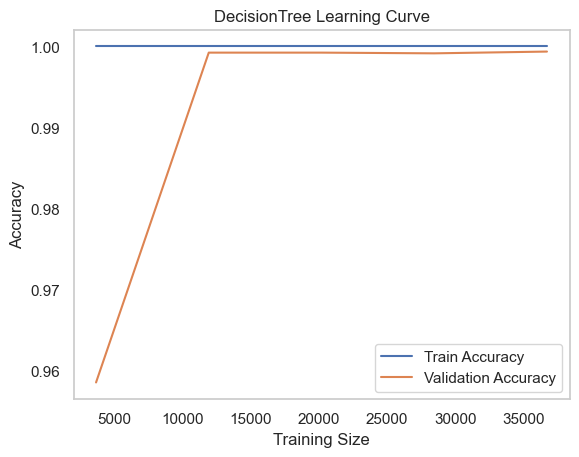


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2633
           1       1.00      1.00      1.00      3662
           2       1.00      1.00      1.00      3316
           3       1.00      1.00      1.00      3986
           4       1.00      1.00      1.00      2186

    accuracy                           1.00     15783
   macro avg       1.00      1.00      1.00     15783
weighted avg       1.00      1.00      1.00     15783

Confusion Matrix:
 [[2625    1    0    5    2]
 [   3 3658    0    1    0]
 [   0    0 3316    0    0]
 [   2    0    0 3984    0]
 [   0    0    0    1 2185]]


In [128]:
# =========================
# Fix: Align Features + DecisionTree Evaluation
# =========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------- Ensure same feature space --------
X_test_final = X_test[X_train_resampled.columns]

# -------- Train --------
dt_model.fit(X_train_resampled, y_train_resampled)

# -------- Predict --------
y_pred_dt = dt_model.predict(X_test_final)

# -------- Accuracy --------
train_accuracy_dt = dt_model.score(X_train_resampled, y_train_resampled)
test_accuracy_dt = accuracy_score(y_test, y_pred_dt)

print(f"DecisionTree - Train Accuracy: {train_accuracy_dt * 100:.2f}%")
print(f"DecisionTree - Test Accuracy: {test_accuracy_dt * 100:.2f}%")

# -------- Cross Validation --------
cv_scores_dt = cross_val_score(
    dt_model,
    X_train_resampled,
    y_train_resampled,
    cv=5,
    scoring='accuracy'
)

print("\nCV Scores:", cv_scores_dt)
print("Mean:", np.mean(cv_scores_dt))
print("Std:", np.std(cv_scores_dt))

# -------- Learning Curve --------
train_sizes, train_scores, test_scores = learning_curve(
    dt_model,
    X_train_resampled,
    y_train_resampled,
    cv=5,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# -------- Plot --------
plt.figure()
plt.plot(train_sizes, train_mean, label='Train Accuracy')
plt.plot(train_sizes, test_mean, label='Validation Accuracy')
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("DecisionTree Learning Curve")
plt.legend()
plt.grid()
plt.show()

# -------- Final Evaluation --------
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

KNN - Train Accuracy: 99.42%
KNN - Test Accuracy: 98.77%

CV Scores: [0.98769465 0.9895459  0.98911031 0.99161494 0.99226832]
Mean: 0.9900468256561037
Std: 0.001676587542538839


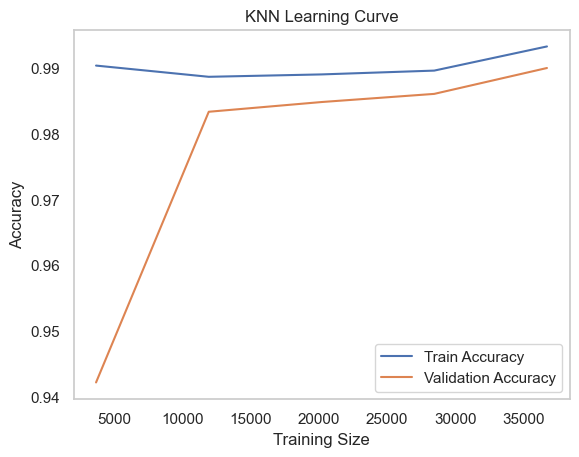


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97      2633
           1       1.00      1.00      1.00      3662
           2       1.00      1.00      1.00      3316
           3       0.97      0.99      0.98      3986
           4       0.99      0.99      0.99      2186

    accuracy                           0.99     15783
   macro avg       0.99      0.99      0.99     15783
weighted avg       0.99      0.99      0.99     15783

Confusion Matrix:
 [[2512   11    0  108    2]
 [   2 3654    0    0    6]
 [   0    0 3315    0    1]
 [  14    7    0 3951   14]
 [   1    0    0   28 2157]]


In [129]:
# =========================
# Fix: Align Features + KNN Evaluation
# =========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------- Ensure same feature space --------
X_test_final = X_test[X_train_resampled.columns]

# -------- Train --------
knn_model.fit(X_train_resampled, y_train_resampled)

# -------- Predict --------
y_pred_knn = knn_model.predict(X_test_final)

# -------- Accuracy --------
train_accuracy_knn = knn_model.score(X_train_resampled, y_train_resampled)
test_accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"KNN - Train Accuracy: {train_accuracy_knn * 100:.2f}%")
print(f"KNN - Test Accuracy: {test_accuracy_knn * 100:.2f}%")

# -------- Cross Validation --------
cv_scores_knn = cross_val_score(
    knn_model,
    X_train_resampled,
    y_train_resampled,
    cv=5,
    scoring='accuracy'
)

print("\nCV Scores:", cv_scores_knn)
print("Mean:", np.mean(cv_scores_knn))
print("Std:", np.std(cv_scores_knn))

# -------- Learning Curve --------
train_sizes, train_scores, test_scores = learning_curve(
    knn_model,
    X_train_resampled,
    y_train_resampled,
    cv=5,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# -------- Plot --------
plt.figure()
plt.plot(train_sizes, train_mean, label='Train Accuracy')
plt.plot(train_sizes, test_mean, label='Validation Accuracy')
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("KNN Learning Curve")
plt.legend()
plt.grid()
plt.show()

# -------- Final Evaluation --------
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

XGBoost Results:
Accuracy: 0.9986694544763353
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2633
           1       1.00      1.00      1.00      3662
           2       1.00      1.00      1.00      3316
           3       1.00      1.00      1.00      3986
           4       1.00      1.00      1.00      2186

    accuracy                           1.00     15783
   macro avg       1.00      1.00      1.00     15783
weighted avg       1.00      1.00      1.00     15783

Confusion Matrix:
 [[2623    2    0    4    4]
 [   2 3655    0    3    2]
 [   0    0 3316    0    0]
 [   3    0    0 3983    0]
 [   1    0    0    0 2185]]


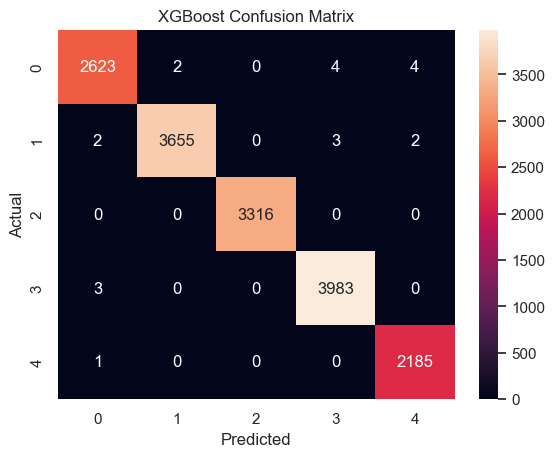

In [130]:
# =========================
# Fix: Align Features + XGBoost (No Mismatch)
# =========================

import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------- Ensure same feature space --------
X_test_final = X_test[X_train_resampled.columns]

# -------- Convert to NumPy --------
X_train_np = X_train_resampled.to_numpy()
X_test_np = X_test_final.to_numpy()
y_train_np = y_train_resampled.to_numpy()
y_test_np = y_test.to_numpy()

# -------- Model --------
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')

# -------- Train --------
xgb_model.fit(X_train_np, y_train_np)

# -------- Predict --------
y_pred = xgb_model.predict(X_test_np)

# -------- Evaluation --------
print("XGBoost Results:")
print("Accuracy:", accuracy_score(y_test_np, y_pred))
print("Classification Report:\n", classification_report(y_test_np, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_np, y_pred))

# -------- Confusion Matrix Plot --------
cm = confusion_matrix(y_test_np, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()